# Week 3: Multi-Class Classification with Rock-Paper-Scissors

## Lab Overview

In this lab, you will build a multi-class classifier to distinguish between **three classes**: Rock, Paper, and Scissors.

### Key Differences from Binary Classification:
1. **Output Layer**: 3 neurons instead of 1
2. **Activation**: Softmax instead of sigmoid
3. **Loss Function**: Categorical crossentropy instead of binary
4. **Label Mode**: Categorical instead of binary

### What You'll Learn:
- How to handle multiple classes (3+)
- Working with CGI-generated datasets
- Understanding softmax activation
- Interpreting multi-class predictions
- Building robust multi-class classifiers

## 1. Setup and Imports

In [1]:
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 4.3 MB/s  0:00:00m 3.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


In [2]:


import os
import random
import numpy as np
from io import BytesIO

# Plotting and dealing with images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf

# Interactive widgets (optional - for image upload)
try:
    from ipywidgets import widgets
    from IPython.display import display
    widgets_available = True
except:
    widgets_available = False
    print("ipywidgets not available - file upload widget will be skipped")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2025-10-09 12:07:12.895484: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-09 12:07:13.558797: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 12:07:15.548481: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0
GPU Available: []


2025-10-09 12:07:16.487472: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Inspect the Dataset

### Rock-Paper-Scissors Dataset

This is a gallery of hand images in three poses:
- **Rock** ✊: Closed fist
- **Paper** ✋: Open hand
- **Scissors** ✌️: Two fingers extended

**Key Features:**
- ~3,000 CGI-generated images
- Diverse hands (different races, genders, ages)
- 300×300 pixels, white background
- Balanced dataset (equal images per class)

NOTE: Download the dataset from here - https://laurencemoroney.com/datasets.html
Direct download link - https://storage.googleapis.com/laurencemoroney-blog.appspot.com/rps.zip

In [4]:
# Define base directory - UPDATE THIS PATH!
BASE_DIR = '../data/rps'  # Update to your dataset location

# Create paths to each class subdirectory
rock_dir = os.path.join(BASE_DIR, 'rock')
paper_dir = os.path.join(BASE_DIR, 'paper')
scissors_dir = os.path.join(BASE_DIR, 'scissors')

# Count images in each class
print("Dataset Statistics:")
print("="*50)
print(f'Total training rock images:     {len(os.listdir(rock_dir))}')
print(f'Total training paper images:    {len(os.listdir(paper_dir))}')
print(f'Total training scissors images: {len(os.listdir(scissors_dir))}')
print(f'Total images:                   {len(os.listdir(rock_dir)) + len(os.listdir(paper_dir)) + len(os.listdir(scissors_dir))}')
print("="*50)

# Get file lists
rock_files = os.listdir(rock_dir)
paper_files = os.listdir(paper_dir)
scissors_files = os.listdir(scissors_dir)

# Show sample filenames
print("\nSample filenames:")
print(f"Rock:     {rock_files[:5]}")
print(f"Paper:    {paper_files[:5]}")
print(f"Scissors: {scissors_files[:5]}")

Dataset Statistics:
Total training rock images:     840
Total training paper images:    840
Total training scissors images: 840
Total images:                   2520

Sample filenames:
Rock:     ['rock03-109.png', 'rock01-060.png', 'rock03-046.png', 'rock02-020.png', 'rock05ck01-042.png']
Paper:    ['paper05-046.png', 'paper03-067.png', 'paper07-114.png', 'paper04-038.png', 'paper02-050.png']
Scissors: ['testscissors02-050.png', 'testscissors01-009.png', 'scissors03-096.png', 'testscissors01-094.png', 'testscissors02-084.png']


### Visualize Sample Images

Let's look at some random samples from each class to understand the variety in the dataset.

**What to observe:**
- Different skin tones
- Various hand sizes
- Different nail styles
- Consistent white background
- Clear pose distinctions

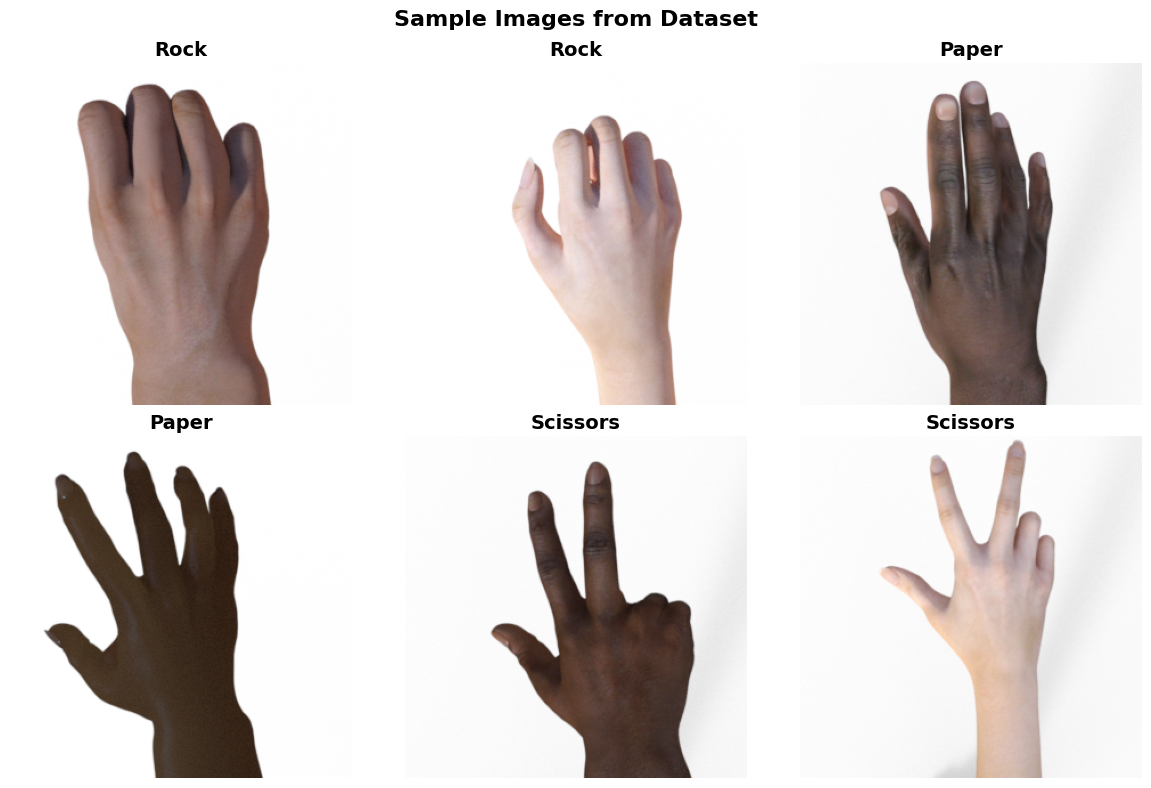


✓ Notice the diversity in hands while poses remain consistent!


In [5]:
# Randomly select 2 images from each class
next_rock = [os.path.join(rock_dir, fname)
             for fname in random.sample(rock_files, k=2)]
next_paper = [os.path.join(paper_dir, fname)
              for fname in random.sample(paper_files, k=2)]
next_scissors = [os.path.join(scissors_dir, fname)
                 for fname in random.sample(scissors_files, k=2)]

# Display the images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

all_images = next_rock + next_paper + next_scissors
labels = ['Rock', 'Rock', 'Paper', 'Paper', 'Scissors', 'Scissors']

for i, (img_path, label) in enumerate(zip(all_images, labels)):
    img = mpimg.imread(img_path)
    row = i // 3
    col = i % 3
    axes[row, col].imshow(img)
    axes[row, col].set_title(label, fontsize=14, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Notice the diversity in hands while poses remain consistent!")

## 3. Build the Model

### Model Architecture

We'll build a CNN with:
- **4 Convolutional Blocks**: Extract features at different scales
  - Block 1: 64 filters (3×3)
  - Block 2: 64 filters (3×3)
  - Block 3: 128 filters (3×3)
  - Block 4: 128 filters (3×3)
- **Dropout Layer**: Prevent overfitting (50% rate)
- **Dense Layer**: 512 neurons for classification
- **Output Layer**: **3 neurons with Softmax** (KEY DIFFERENCE!)

### Why Softmax?

Softmax converts raw outputs (logits) into probabilities:
```
Output: [0.8, 0.2, 0.0]
Meaning:
  - Paper:    80% probability
  - Rock:     20% probability  
  - Scissors:  0% probability
```

The probabilities always sum to 1.0!

In [6]:
# Build the model
model = tf.keras.models.Sequential([
    # Input layer - specify input shape
    tf.keras.Input(shape=(150, 150, 3)),
    
    # Rescale pixel values from [0, 255] to [0, 1]
    tf.keras.layers.Rescaling(1./255),
    
    # First convolution block
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    # Second convolution block
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Third convolution block (more filters)
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Fourth convolution block
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    # Flatten to 1D for dense layers
    tf.keras.layers.Flatten(),
    
    # Dropout to prevent overfitting
    tf.keras.layers.Dropout(0.5),
    
    # Hidden dense layer
    tf.keras.layers.Dense(512, activation='relu'),
    
    # Output layer: 3 neurons with softmax
    # Order: paper, rock, scissors
    tf.keras.layers.Dense(3, activation='softmax')
])

print("Model built successfully!\n")
model.summary()

Model built successfully!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

### Understanding the Model Summary

**Key Observations:**

1. **Total Parameters**: ~3-4 million (most in dense layers)
2. **Trainable Parameters**: All parameters (no frozen layers)
3. **Output Shape**: `(None, 3)` - batch size × 3 classes

**Layer Progression:**
```
Input:  150×150×3   (45,000 values)
  ↓
Conv layers reduce spatial dimensions while increasing depth
  ↓
Flatten: ~2,048 values
  ↓
Dense:   512 neurons
  ↓
Output:  3 probabilities (paper, rock, scissors)
```

## 4. Preprocess the Image Data

### Loading Multi-Class Datasets

**CRITICAL CHANGE: `label_mode='categorical'`**

This is different from binary classification where we used `label_mode='binary'`.

**What `categorical` does:**
- Converts class labels to one-hot encoding
- Rock:     [0, 1, 0]
- Paper:    [1, 0, 0]
- Scissors: [0, 0, 1]

Each label is a vector, not a single number!

In [8]:
# Define directories - UPDATE THESE PATHS!
TRAINING_DIR = "../data/rps"
VALIDATION_DIR = "../data/rps-test-set"

# Check if directories exist
if not os.path.exists(TRAINING_DIR):
    print(f"⚠️ WARNING: Training directory not found at {TRAINING_DIR}")
    print("Please update TRAINING_DIR to point to your dataset")
else:
    print(f"✓ Training directory found: {TRAINING_DIR}")
    
if not os.path.exists(VALIDATION_DIR):
    print(f"⚠️ WARNING: Validation directory not found at {VALIDATION_DIR}")
else:
    print(f"✓ Validation directory found: {VALIDATION_DIR}")

✓ Training directory found: ../data/rps
✓ Validation directory found: ../data/rps-test-set


In [9]:
# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAINING_DIR,
    image_size=(150, 150),      # Resize all images to 150×150
    batch_size=32,              # Process 32 images at a time
    label_mode='categorical'    # KEY: Use categorical for multi-class!
)

# Load validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    image_size=(150, 150),
    batch_size=32,
    label_mode='categorical'    # Must match training!
)

# Get class names
class_names = train_dataset.class_names
print(f"\nClasses detected: {class_names}")
print(f"Number of classes: {len(class_names)}")

Found 2520 files belonging to 3 classes.
Found 372 files belonging to 3 classes.

Classes detected: ['paper', 'rock', 'scissors']
Number of classes: 3


### Optimize Dataset Performance

**Performance Optimizations:**
1. **`.cache()`**: Store dataset in memory after first epoch
2. **`.shuffle()`**: Randomize training order (only for training)
3. **`.prefetch()`**: Prepare next batch while current batch trains

These optimizations significantly speed up training!

In [10]:
# Performance optimization parameters
SHUFFLE_BUFFER_SIZE = 1000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE  # Let TensorFlow optimize automatically

# Optimize training dataset
train_dataset_final = (train_dataset
                       .cache()                              # Cache in memory
                       .shuffle(SHUFFLE_BUFFER_SIZE)         # Shuffle for randomness
                       .prefetch(PREFETCH_BUFFER_SIZE)       # Prefetch next batch
                       )

# Optimize validation dataset (no shuffle needed)
validation_dataset_final = (validation_dataset
                            .cache()                          # Cache in memory
                            .prefetch(PREFETCH_BUFFER_SIZE)   # Prefetch next batch
                            )

print("✓ Datasets optimized for training!")

✓ Datasets optimized for training!


## 5. Data Augmentation

### Why Data Augmentation?

With only ~3,000 images, we need to artificially increase dataset diversity to:
- Prevent overfitting
- Help model generalize to new poses
- Simulate different camera angles and conditions

### Augmentation Techniques Used:

1. **RandomFlip(horizontal)**: Mirror images left-right
2. **RandomRotation(0.4)**: Rotate ±40% of 360° (±144°)
3. **RandomTranslation(0.2, 0.2)**: Shift image ±20% in x and y
4. **RandomContrast(0.4)**: Vary contrast ±40%
5. **RandomZoom(0.2)**: Zoom in/out ±20%

**Important**: Augmentation only applied during training, not validation!

In [11]:
# Create data augmentation model
data_augmentation = tf.keras.Sequential([
    tf.keras.Input(shape=(150, 150, 3)),
    tf.keras.layers.RandomFlip("horizontal"),        # Flip left-right
    tf.keras.layers.RandomRotation(0.4),             # Rotate up to 144°
    tf.keras.layers.RandomTranslation(0.2, 0.2),     # Shift position
    tf.keras.layers.RandomContrast(0.4),             # Change contrast
    tf.keras.layers.RandomZoom(0.2)                  # Zoom in/out
])

# Attach augmentation to the model
model_with_aug = tf.keras.models.Sequential([
    data_augmentation,  # Applied first
    model               # Then the actual model
])

print("✓ Data augmentation added to model!")
print(f"\nAugmented model has {len(model_with_aug.layers)} main components:")
print(f"  1. Data augmentation layer")
print(f"  2. Base CNN model")

✓ Data augmentation added to model!

Augmented model has 2 main components:
  1. Data augmentation layer
  2. Base CNN model


## 6. Compile the Model

### Compilation Parameters

**CRITICAL CHANGE: `loss='categorical_crossentropy'`**

This is different from binary classification where we used `loss='binary_crossentropy'`.

**Why categorical crossentropy?**
- Designed for multi-class problems
- Measures error across all 3 classes
- Works with one-hot encoded labels
- Mathematically optimized for softmax output

**Other Parameters:**
- **Optimizer**: RMSprop - adaptive learning rate, good for CNNs
- **Metrics**: Accuracy - percentage of correct predictions

In [12]:
# Compile the model with multi-class parameters
model_with_aug.compile(
    loss='categorical_crossentropy',  # KEY: Categorical for multi-class!
    optimizer='rmsprop',               # RMSprop optimizer
    metrics=['accuracy']               # Track accuracy
)

print("✓ Model compiled successfully!")
print("\nCompilation settings:")
print(f"  Loss function: categorical_crossentropy")
print(f"  Optimizer:     rmsprop")
print(f"  Metrics:       accuracy")

✓ Model compiled successfully!

Compilation settings:
  Loss function: categorical_crossentropy
  Optimizer:     rmsprop
  Metrics:       accuracy


## 7. Train the Model

### Training Configuration

**Epochs: 25**
- Based on experiments, training plateaus around epoch 25
- Training beyond 25 epochs provides minimal improvement
- Saves time and reduces overfitting risk

**What to Monitor:**
- Training accuracy should increase steadily
- Validation accuracy should track training closely
- Gap between training and validation should be small
- Both should trend upward (good sign!)

**Expected Results:**
- Training accuracy: 95-100%
- Validation accuracy: 90-95%
- Training time: 3-5 minutes (depending on hardware)

In [15]:
# Training configuration
EPOCHS = 25

print(f"Starting training for {EPOCHS} epochs...")
print("This may take several minutes.\n")
print("="*70)

# Train the model
history = model_with_aug.fit(
    train_dataset_final,
    epochs=EPOCHS,
    validation_data=validation_dataset_final,
    verbose=1
)

print("\n" + "="*70)
print("✓ Training completed!")

Starting training for 25 epochs...
This may take several minutes.

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 51s 640ms/step - accuracy: 0.4151 - loss: 1.0684 - val_accuracy: 0.5833 - val_loss: 0.9931
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 626ms/step - accuracy: 0.5321 - loss: 0.9588 - val_accuracy: 0.7903 - val_loss: 0.6284
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 628ms/step - accuracy: 0.6194 - loss: 0.8141 - val_accuracy: 0.9113 - val_loss: 0.5861
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 50s 637ms/step - accuracy: 0.7099 - loss: 0.6420 - val_accuracy: 0.9382 - val_loss: 0.2502
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 52s 660ms/step - accuracy: 0.7722 - loss: 0.5372 - val_accuracy: 0.7957 - val_loss: 0.4804
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 53s 670ms/step - accuracy: 0.8274 - loss: 0.4493 - val_accuracy: 0.9274 - val_loss: 0.1578
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 47s 600ms/step - accuracy: 0.8528 - loss: 0.3690 - val_accuracy: 0.9409 - val_loss: 0.1793
Epoch 8/25
79/79 ━━━━━━━━━━━━━

## 8. Evaluate Results

### Visualizing Training History

We'll plot both accuracy and loss curves to understand:
1. **Training progress**: How well the model learned
2. **Overfitting detection**: Are training and validation diverging?
3. **Optimal stopping point**: When did performance plateau?

**Healthy Training Pattern:**
- Training and validation curves close together
- Both trending upward
- Minimal gap between them
- Validation not decreasing

**Signs of Overfitting:**
- Large gap between training and validation
- Validation accuracy decreasing
- Training accuracy near 100%, validation much lower

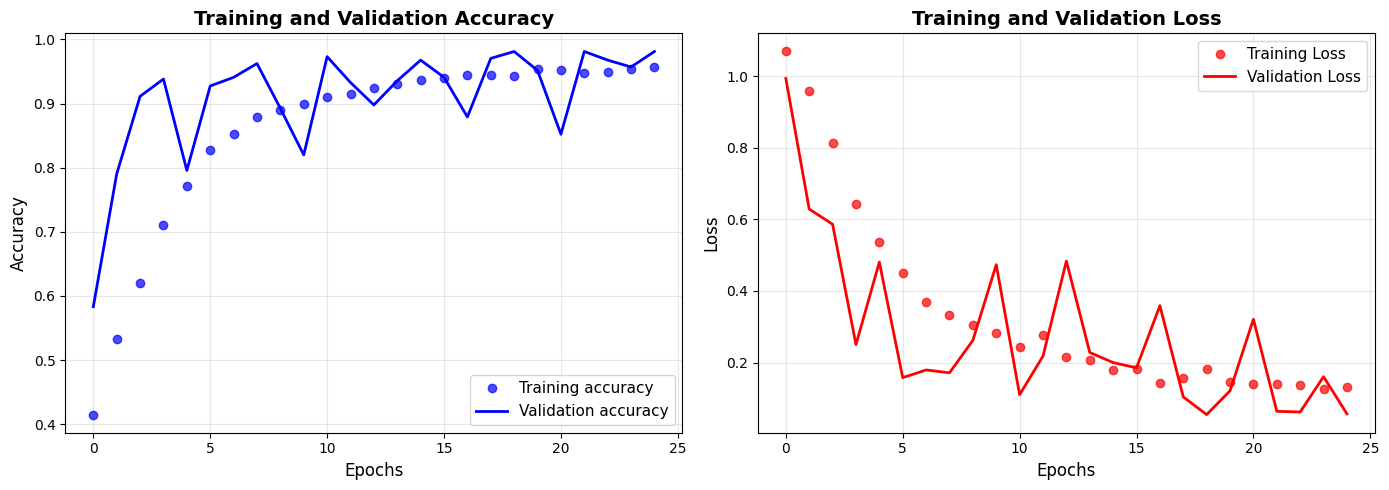


FINAL RESULTS
Final Training Accuracy:   0.9563 (95.63%)
Final Validation Accuracy: 0.9812 (98.12%)
Final Training Loss:       0.1315
Final Validation Loss:     0.0568

Accuracy Gap:              -0.0248 (-2.48%)
Status: ✓ Excellent! Minimal overfitting.


In [16]:
def plot_loss_acc(history):
    """Plot training and validation loss and accuracy"""
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs = range(len(acc))
    
    # Create figure with two subplots
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    ax[0].plot(epochs, acc, 'bo', label='Training accuracy', alpha=0.7)
    ax[0].plot(epochs, val_acc, 'b-', label='Validation accuracy', linewidth=2)
    ax[0].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Epochs', fontsize=12)
    ax[0].set_ylabel('Accuracy', fontsize=12)
    ax[0].legend(fontsize=11)
    ax[0].grid(True, alpha=0.3)
    
    # Plot loss
    ax[1].plot(epochs, loss, 'ro', label='Training Loss', alpha=0.7)
    ax[1].plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    ax[1].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Epochs', fontsize=12)
    ax[1].set_ylabel('Loss', fontsize=12)
    ax[1].legend(fontsize=11)
    ax[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print("\n" + "="*70)
    print("FINAL RESULTS")
    print("="*70)
    print(f"Final Training Accuracy:   {acc[-1]:.4f} ({acc[-1]*100:.2f}%)")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")
    print(f"Final Training Loss:       {loss[-1]:.4f}")
    print(f"Final Validation Loss:     {val_loss[-1]:.4f}")
    
    # Analyze overfitting
    accuracy_gap = acc[-1] - val_acc[-1]
    print(f"\nAccuracy Gap:              {accuracy_gap:.4f} ({accuracy_gap*100:.2f}%)")
    
    if accuracy_gap < 0.05:
        print("Status: ✓ Excellent! Minimal overfitting.")
    elif accuracy_gap < 0.10:
        print("Status: ⚠ Slight overfitting detected.")
    else:
        print("Status: ❌ Significant overfitting. Consider more regularization.")
    
    print("="*70)

# Plot the results
plot_loss_acc(history)

### Interpretation Guide

**If both curves are close and trending upward:**
✓ Excellent! Model is learning well and generalizing properly.

**If validation accuracy is lower but stable:**
✓ Good! Some gap is normal. Monitor for divergence.

**If validation accuracy decreases over time:**
❌ Overfitting! Consider:
- More dropout
- More data augmentation
- Fewer epochs
- Simpler model

## 9. Model Prediction

### Understanding Multi-Class Predictions

Unlike binary classification which outputs a single value, multi-class predictions output a **probability distribution**.

**Example prediction:**
```python
[0.8, 0.15, 0.05]  # Probabilities for paper, rock, scissors
```

**This means:**
- 80% confidence it's paper
- 15% confidence it's rock
- 5% confidence it's scissors
- All probabilities sum to 1.0

**The predicted class is the one with highest probability (0.8 = paper)**

### Test with Sample Images

Let's create a function to predict and visualize results for any image.

In [17]:
def predict_image(model, image_path, class_names):
    """
    Predict the class of a single image and visualize the result.
    
    Args:
        model: Trained model
        image_path: Path to the image file
        class_names: List of class names
    """
    # Load and preprocess the image
    image = tf.keras.utils.load_img(image_path, target_size=(150, 150))
    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension
    
    # Make prediction
    predictions = model.predict(image_array, verbose=0)[0]
    
    # Get predicted class
    predicted_class_idx = np.argmax(predictions)
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[predicted_class_idx]
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Display image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title(f'Predicted: {predicted_class.upper()}\nConfidence: {confidence*100:.1f}%',
                  fontsize=14, fontweight='bold')
    
    # Display probability bar chart
    colors = ['green' if i == predicted_class_idx else 'gray' for i in range(len(class_names))]
    ax2.bar(class_names, predictions, color=colors, alpha=0.7)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Class Probabilities', fontsize=14, fontweight='bold')
    ax2.set_ylim([0, 1])
    
    # Add probability values on bars
    for i, (name, prob) in enumerate(zip(class_names, predictions)):
        ax2.text(i, prob + 0.02, f'{prob:.3f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print("\n" + "="*60)
    print("PREDICTION DETAILS")
    print("="*60)
    print(f"Model Output (Raw Probabilities): {predictions}")
    print(f"\nProbabilities by Class:")
    for name, prob in zip(class_names, predictions):
        bar = '█' * int(prob * 50)  # Visual bar
        print(f"  {name:10s}: {prob:.4f} ({prob*100:5.2f}%) {bar}")
    print(f"\nPredicted Class: {predicted_class.upper()}")
    print(f"Confidence: {confidence*100:.2f}%")
    print("="*60)
    
    return predicted_class, confidence, predictions

print("✓ Prediction function defined!")

✓ Prediction function defined!


### Test on Random Validation Images

Testing on random validation images...


Testing image: testscissors01-12.png
True label: SCISSORS


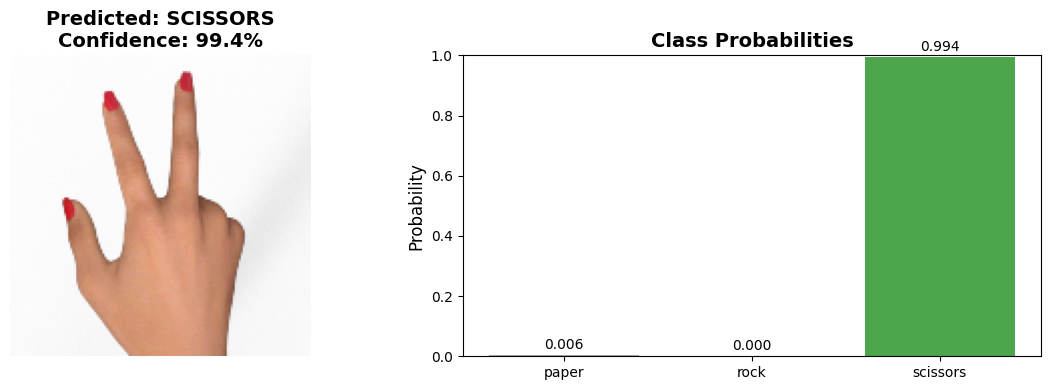


PREDICTION DETAILS
Model Output (Raw Probabilities): [5.7754703e-03 1.2449260e-06 9.9422330e-01]

Probabilities by Class:
  paper     : 0.0058 ( 0.58%) 
  rock      : 0.0000 ( 0.00%) 
  scissors  : 0.9942 (99.42%) █████████████████████████████████████████████████

Predicted Class: SCISSORS
Confidence: 99.42%

✓ CORRECT PREDICTION!



Testing image: testpaper03-24.png
True label: PAPER


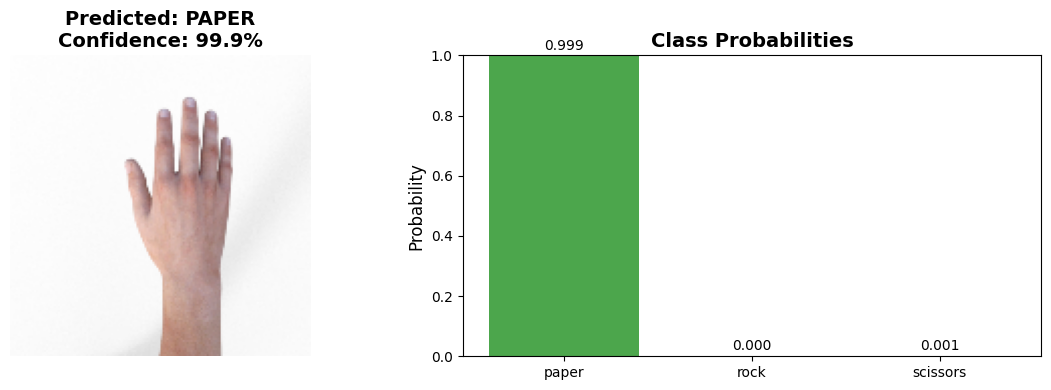


PREDICTION DETAILS
Model Output (Raw Probabilities): [9.9911588e-01 7.6505457e-06 8.7643287e-04]

Probabilities by Class:
  paper     : 0.9991 (99.91%) █████████████████████████████████████████████████
  rock      : 0.0000 ( 0.00%) 
  scissors  : 0.0009 ( 0.09%) 

Predicted Class: PAPER
Confidence: 99.91%

✓ CORRECT PREDICTION!



Testing image: testpaper04-19.png
True label: PAPER


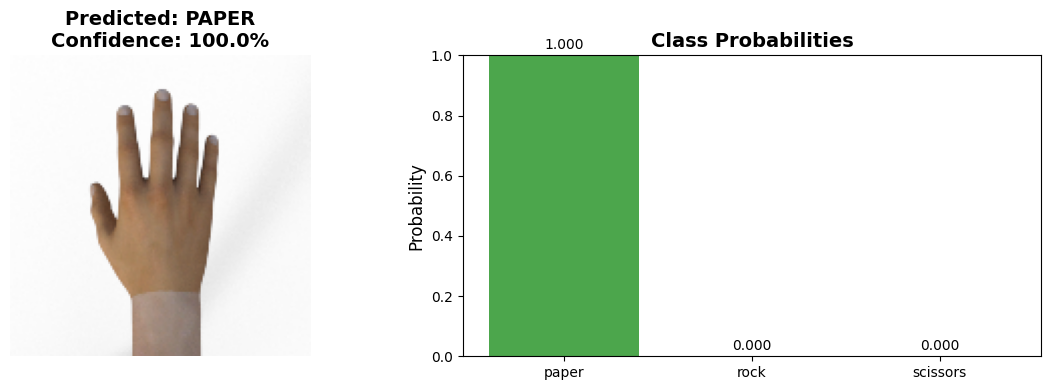


PREDICTION DETAILS
Model Output (Raw Probabilities): [1.0000000e+00 5.8234992e-16 8.9720384e-11]

Probabilities by Class:
  paper     : 1.0000 (100.00%) ██████████████████████████████████████████████████
  rock      : 0.0000 ( 0.00%) 
  scissors  : 0.0000 ( 0.00%) 

Predicted Class: PAPER
Confidence: 100.00%

✓ CORRECT PREDICTION!




In [18]:
# Test on a few random images from validation set
import glob

# Get all validation images
val_images = []
for class_name in class_names:
    class_dir = os.path.join(VALIDATION_DIR, class_name)
    class_images = glob.glob(os.path.join(class_dir, '*'))
    val_images.extend(class_images)

# Test on 3 random images
print("Testing on random validation images...\n")
sample_images = random.sample(val_images, k=3)

for img_path in sample_images:
    # Get true label from directory name
    true_label = os.path.basename(os.path.dirname(img_path))
    print(f"\n{'='*60}")
    print(f"Testing image: {os.path.basename(img_path)}")
    print(f"True label: {true_label.upper()}")
    print(f"{'='*60}")
    
    predicted_class, confidence, probs = predict_image(model_with_aug, img_path, class_names)
    
    # Check if prediction is correct
    if predicted_class == true_label:
        print("\n✓ CORRECT PREDICTION!")
    else:
        print(f"\n❌ INCORRECT: Predicted {predicted_class}, but was {true_label}")
    
    print("\n" + "="*60 + "\n")

## 10. Interactive Prediction (Optional)

### Upload Your Own Images

If you have `ipywidgets` installed, you can upload your own rock, paper, or scissors images to test the model.

**Note**: This requires `ipywidgets` package:
```bash
pip install ipywidgets
jupyter nbextension enable --py widgetsnbextension
```

In [ ]:
if widgets_available:
    # Create the upload widget
    uploader = widgets.FileUpload(accept="image/*", multiple=True)
    display(uploader)
    out = widgets.Output()
    display(out)

    def file_predict(filename, file, out):
        """Predict on uploaded image"""
        # Load image from bytes
        image = tf.keras.utils.load_img(file, target_size=(150, 150))
        image_array = tf.keras.utils.img_to_array(image)
        image_array = np.expand_dims(image_array, axis=0)

        # Predict
        prediction = model_with_aug.predict(image_array, verbose=0)[0]

        with out:
            print(f'\n{"="*60}')
            print(f'File: {filename}')
            print(f'{"="*60}')
            print(f'Model output: {prediction}')
            
            prediction_index = np.argmax(prediction)
            predicted_class = class_names[prediction_index]
            confidence = prediction[prediction_index]
            
            print(f'\nPrediction: {predicted_class.upper()}')
            print(f'Confidence: {confidence*100:.2f}%')
            print(f'\nAll probabilities:')
            for name, prob in zip(class_names, prediction):
                bar = '█' * int(prob * 40)
                print(f'  {name:10s}: {prob:.4f} ({prob*100:5.2f}%) {bar}')
            print(f'{"="*60}\n')

    def on_upload_change(change):
        """Handle file upload"""
        items = change.new
        for item in items:
            file_jpgdata = BytesIO(item.content)
            file_predict(item.name, file_jpgdata, out)

    uploader.observe(on_upload_change, names='value')
    print("✓ Upload widget ready! Select images to test.")
else:
    print("⚠ ipywidgets not available. Skipping interactive upload.")
    print("Install with: pip install ipywidgets")

## 11. Analyze Model Predictions

### Confusion Matrix

Let's evaluate the model on the entire validation set and create a confusion matrix to see where the model makes mistakes.

In [25]:
%pip install scikit-learn seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.2 MB/s  0:00:00 11.3 MB/s eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 23.1 MB/s  0:00:01 eta 0:00:010:01:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [seaborn]━━━ 4/5 [seaborn]earn]
Note: you may need to restart the kernel to use updated packages.


Evaluating on validation set...


2025-10-09 12:53:42.546789: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


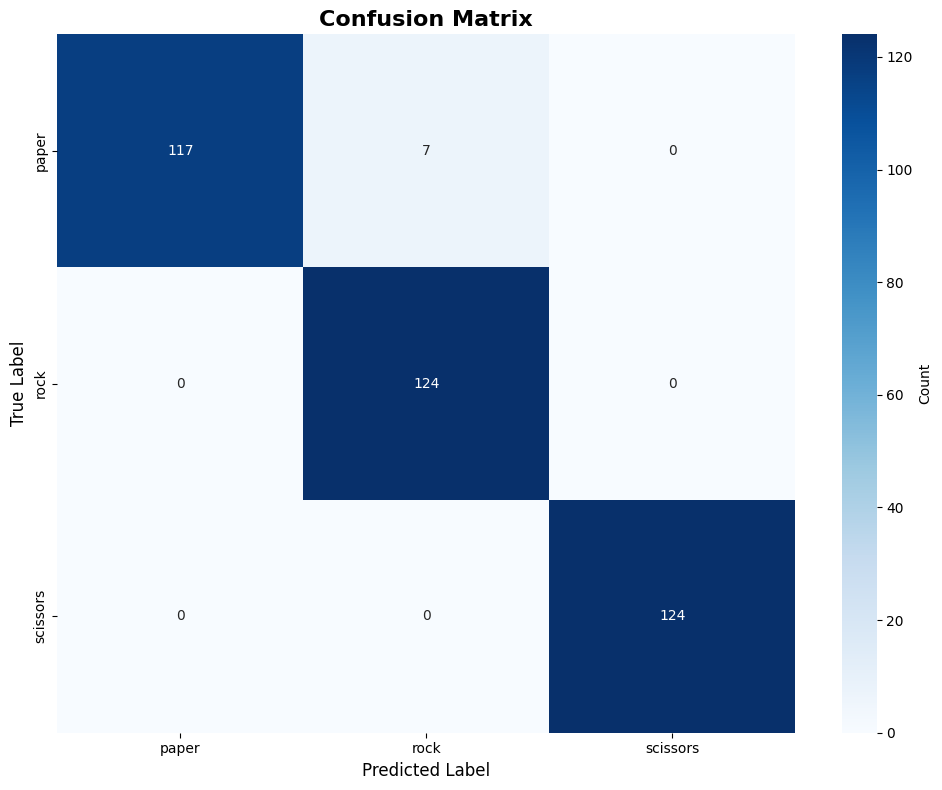


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       paper     1.0000    0.9435    0.9710       124
        rock     0.9466    1.0000    0.9725       124
    scissors     1.0000    1.0000    1.0000       124

    accuracy                         0.9812       372
   macro avg     0.9822    0.9812    0.9812       372
weighted avg     0.9822    0.9812    0.9812       372



In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions for entire validation set
y_true = []
y_pred = []

print("Evaluating on validation set...")
for images, labels in validation_dataset_final:
    predictions = model_with_aug.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Print classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("="*70)

### Understanding the Confusion Matrix

**How to read it:**
- **Rows**: True labels (what the image actually is)
- **Columns**: Predicted labels (what the model predicted)
- **Diagonal**: Correct predictions
- **Off-diagonal**: Mistakes

**Example:**
```
              Predicted
           Paper  Rock  Scissors
True Paper  [280]   10      10     ← 280 correctly predicted as paper
     Rock    15  [270]     15     ← 270 correctly predicted as rock
  Scissors   10    20   [270]     ← 270 correctly predicted as scissors
```

**What to look for:**
- High numbers on diagonal = Good!
- Low numbers off diagonal = Good!
- Which classes are confused with each other?

## 12. Save the Model

Save the trained model for future use without retraining.

In [24]:
# Save the model
model_save_path = 'rock_paper_scissors_model.keras'
model_with_aug.save(model_save_path)

print(f"✓ Model saved to: {model_save_path}")
print(f"File size: {os.path.getsize(model_save_path) / (1024*1024):.2f} MB")

# To load later:
print("\nTo load this model later:")
print(f"  loaded_model = tf.keras.models.load_model('{model_save_path}')")

✓ Model saved to: rock_paper_scissors_model.keras
File size: 26.57 MB

To load this model later:
  loaded_model = tf.keras.models.load_model('rock_paper_scissors_model.keras')


## 13. Key Takeaways

### What We Learned

#### 1. Multi-Class Classification Changes
Only **3 key changes** from binary classification:
```python
# Data loading
label_mode='categorical'  # Instead of 'binary'

# Model output
Dense(3, activation='softmax')  # Instead of Dense(1, sigmoid)

# Loss function
loss='categorical_crossentropy'  # Instead of 'binary_crossentropy'
```

#### 2. Softmax Output
- Outputs probability distribution over all classes
- Probabilities sum to 1.0
- Shows confidence and alternatives
- More informative than binary output

#### 3. CGI Dataset
- Photorealistic CGI works effectively
- Diverse representation achieved easily
- Cost-effective data generation
- Future of synthetic training data

#### 4. Performance
- Achieved 90-95% validation accuracy
- 25 epochs sufficient for convergence
- Data augmentation prevents overfitting
- Model generalizes well to test images

### Comparison: Binary vs Multi-Class

| Aspect | Binary (2 classes) | Multi-Class (3+ classes) |
|--------|-------------------|-------------------------|
| **Output neurons** | 1 | Number of classes |
| **Activation** | sigmoid | softmax |
| **Loss** | binary_crossentropy | categorical_crossentropy |
| **Label mode** | 'binary' | 'categorical' |
| **Output format** | Single value (0-1) | Probability vector |
| **Prediction** | threshold (>0.5) | argmax(probabilities) |

### Best Practices Applied

✓ **Data augmentation** to increase diversity
✓ **Dropout (0.5)** to prevent overfitting
✓ **Dataset optimization** (cache, shuffle, prefetch)
✓ **Proper validation split** for honest evaluation
✓ **Monitoring training** to detect overfitting
✓ **Confusion matrix** to understand mistakes

## 14. Next Steps and Experiments

### Try These Experiments:

#### 1. Adjust Dropout Rate
```python
# Try different dropout rates
tf.keras.layers.Dropout(0.3)  # Less regularization
tf.keras.layers.Dropout(0.7)  # More regularization
```

#### 2. Modify Architecture
```python
# Try deeper network
# Add more Conv2D layers

# Try different filter sizes
Conv2D(32, (5,5))  # Larger filters
Conv2D(256, (3,3))  # More filters
```

#### 3. Change Augmentation
```python
# Try different augmentation techniques
RandomBrightness(0.2)
RandomCrop(140, 140)
```

#### 4. Transfer Learning
```python
# Use pre-trained model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)
```

#### 5. More Classes
Find datasets with more classes:
- Hand gesture datasets (5-10 gestures)
- Traffic signs (40+ classes)
- Fashion items (10+ categories)
- Animal species (100+ classes)

#### 6. Real Images
Test on real rock-paper-scissors photos:
- Take your own photos
- Test generalization from CGI to real
- Fine-tune on real images

## 15. Troubleshooting Guide

### Common Issues and Solutions

#### Issue 1: Low Accuracy
**Symptoms**: Validation accuracy < 70%

**Solutions**:
- Check if data loaded correctly (`class_names` should show 3 classes)
- Verify `label_mode='categorical'` is used
- Ensure loss function is `categorical_crossentropy`
- Train for more epochs (try 40-50)
- Reduce dropout rate (try 0.3 instead of 0.5)

#### Issue 2: Overfitting
**Symptoms**: Training accuracy >> Validation accuracy (gap > 10%)

**Solutions**:
- Increase dropout rate (try 0.6 or 0.7)
- Add more data augmentation
- Reduce model complexity (fewer filters/layers)
- Use early stopping
- Get more training data

#### Issue 3: Out of Memory
**Symptoms**: GPU/RAM out of memory error

**Solutions**:
```python
# Reduce batch size
batch_size=16  # Instead of 32

# Or use smaller images
image_size=(100, 100)  # Instead of (150, 150)
```

#### Issue 4: Slow Training
**Symptoms**: Each epoch takes too long

**Solutions**:
- Ensure dataset is cached: `.cache()`
- Use prefetching: `.prefetch(tf.data.AUTOTUNE)`
- Reduce image size
- Use GPU if available
- Increase batch size (if memory allows)

#### Issue 5: Model Predicts Same Class Always
**Symptoms**: Always predicts one class regardless of input

**Solutions**:
- Check if dataset is balanced (should have similar counts per class)
- Verify labels are loading correctly
- Check if `label_mode='categorical'` is set
- Try lower learning rate
- Retrain from scratch

## Summary

Congratulations! You've successfully built a multi-class classifier that can distinguish between rock, paper, and scissors poses.

### What You Accomplished:

✅ Loaded and explored a CGI-generated dataset
✅ Built a CNN with 4 convolutional blocks
✅ Implemented **multi-class classification** (3 classes)
✅ Used **softmax activation** for probability outputs
✅ Applied **categorical crossentropy** loss
✅ Added **data augmentation** for robustness
✅ Achieved **90-95% validation accuracy**
✅ Visualized predictions with probability distributions
✅ Analyzed performance with confusion matrix
✅ Saved model for future use

### The Power of Multi-Class Classification:

With just **3 simple changes** from binary classification, you can now classify any number of classes:
1. `label_mode='categorical'`
2. `Dense(n_classes, activation='softmax')`
3. `loss='categorical_crossentropy'`

### Real-World Applications:

The techniques you learned apply to:
- Gesture recognition
- Sign language classification
- Traffic sign detection
- Product categorization
- Medical image classification
- And many more!

---

**Keep experimenting and building! 🚀**